# Frequency Distribution

## Imports

In [2]:
from helper import *
from caen_digitizer import *

# data
import uproot
import numpy as np
import awkward as ak
import polars as pl

# plotting
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter

In [ ]:
plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 10, 
    "legend.fontsize": 13, 
    "legend.labelspacing": 0.2, 
    "figure.dpi": 100, 
    "text.usetex": False,
    "text.latex.preamble": r"\usepackage{sfmath}",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})



## Retrieve data

In [25]:
fileDir = "/Users/andyyu/Documents/Python/HEP/dawson_hep/scintillating_chamber/data_analysis/data"
k0 = 1
k1 = 34
dfs = []
for runNo in range(k0, k1 + 1):
    data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in range(17, 27) ], signal_filter='converted')

    dfs.append(data)

In [ ]:
dfs[0].waveforms["wave"][:,1].shape

(10000, 924)

## Masking Function

In [83]:
def getMaxMask(data, getMask):

    ch_event = getMask(0, data)

    for _channel_trigger in range(1,10):

        masked = getMask(_channel_trigger, data)


        if masked[0].shape[0] > ch_event[0].shape[0]:
            ch_event = masked
    

    return ch_event[0]

def getThresholdMask(_channel_trigger, data):
    signal_max = data.waveforms['amplitude'][:, _channel_trigger]
    signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)
    mask_event = (signal_min > -15) & (signal_max > 10)

    return np.where(mask_event)

def getSNRMask(_channel_trigger, data):

    samples = 50
    sample_head = data.waveforms["wave"][2][_channel_trigger][:samples]

    mean = np.mean(np.abs(sample_head))

    SNR = sample_head.max() / mean

    SNR_factor = 2
    signal_max = data.waveforms['amplitude'][:, _channel_trigger]

    signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)

    mask_event = (signal_min > -15) & (signal_max > SNR * SNR_factor)

    return np.where(mask_event)

getSNRMask(2, dfs[0])


(array([  93,  121,  201,  249,  438,  710,  732,  883, 1016, 1259, 1433,
        1455, 1541, 1723, 1733, 1833, 1892, 2107, 2116, 2369, 2424, 2558,
        2560, 2656, 2667, 2963, 2978, 3013, 3044, 3227, 3365, 3576, 3946,
        4062, 4068, 4131, 4279, 4475, 4743, 4817, 4842, 4849, 5034, 5354,
        5423, 5484, 5743, 6037, 6375, 6473, 6482, 6606, 6611, 6720, 6764,
        6911, 6969, 7075, 7429, 7430, 7532, 7774, 7821, 7990, 8240, 8241,
        8267, 8312, 8357, 8385, 8454, 8598, 8645, 9072, 9123, 9216, 9598,
        9692, 9763, 9888]),)

## Get Rates

In [85]:
def getRates(dfs, mask_f = getThresholdMask):
    rates = []

    for file in dfs:
        selected_events = len(getMaxMask(file, mask_f))
        r = selected_events / len(file.waveforms['wave'])
        rates.append(r)
    return rates

threshold_rates = getRates(dfs)
SNR_rates = getRates(dfs, mask_f = getSNRMask)






In [87]:
# combination
# k1 = 34
set1 = threshold_rates[:17]
set2 = threshold_rates[17:34]
total_threshold_rates = []
for i in range(k1//2):
    total_threshold_rates.append(set1[i])
    total_threshold_rates.append(set2[i])

set1 = SNR_rates[:17]
set2 = SNR_rates[17:34]
total_SNR_rates = []
for i in range(k1//2):
    total_SNR_rates.append(set1[i])
    total_SNR_rates.append(set2[i])


# total
print(total_threshold_rates)
print(total_SNR_rates)

[0.1557, 0.1526, 0.5585, 0.3499, 0.8152, 0.7738, 0.8485, 0.8469, 0.8443, 0.8525, 0.8501, 0.8515, 0.8039, 0.845, 0.5719, 0.7432, 0.7622, 0.603, 0.847, 0.8371, 0.8567, 0.8531, 0.847, 0.8578, 0.8231, 0.8534, 0.7613, 0.8396, 0.4064, 0.6177, 0.0832, 0.1603, 0.0244, 0.0229]
[0.1591, 0.7859, 0.8211, 0.3826, 0.8157, 0.7749, 0.8489, 0.8472, 0.8444, 0.8527, 0.8502, 0.8517, 0.805, 0.8454, 0.7311, 0.757, 0.7654, 0.606, 0.8474, 0.8381, 0.8568, 0.8534, 0.8473, 0.8581, 0.8251, 0.8536, 0.7721, 0.84, 0.4564, 0.6191, 0.3683, 0.5859, 0.5828, 0.5838]


In [ ]:
dip = []
for i in range(len(total) - 1):
    if total[i] < total[i+1]:
        dip.append(i)
    

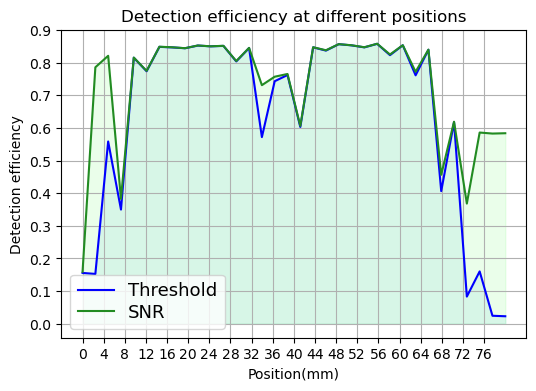

Standard Deviation:nan


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [92]:
x = np.linspace(0,80,34)
y_t = np.array(total_threshold_rates)
y_s = np.array(total_SNR_rates)


# #Smoothing the line
# # moving average
# window = 5  # number of points to average
# #Basically, this line creates a matrix of length window, and divides it(meaning it is taking the mean), 
# y_s = np.convolve(y, np.ones(window)/window, mode='same')


plt.plot(x,y, color = "blue", label = f"Threshold")
plt.plot(x,y_s, color = "forestgreen", label = f"SNR")

plt.fill_between(x,y, color= "skyblue", alpha = 0.2)
plt.fill_between(x,y_s, color= "palegreen", alpha = 0.2)

plt.xticks(np.arange(0,80,4))
plt.yticks(np.arange(0,1,0.1))

plt.xlabel("Position(mm)")
plt.ylabel("Detection efficiency")
plt.title("Detection efficiency at different positions")
plt.grid(True)
plt.legend()
plt.show()

std = np.std(total)
print(f"Standard Deviation:{std}")

# 3D 

## Graph

#Create distribution
R2D = np.outer(rates_y, rates_x)

x = len(rates_x)
y = len(rates_y)
X, Y = np.meshgrid(x,y)

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

ax.plot_surface(X, Y, R2D, cmap = "terrain")
ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Hit Rate")

plt.show()